# v5 presentation visuals — slide-prep gallery

**Purpose:** browse every figure + table produced by `scripts/build_v5_report.py`
in one place, with light commentary, so you can cherry-pick visuals for the
PM-facing slide deck.

**How to refresh:** re-run `PYTHONPATH=src python3 scripts/build_v5_report.py`
from the repo root after any retrain / Risk Index / freeze pass; the PNGs and
CSV/MD tables under `dist/v5/report/` get rewritten in place and this notebook
picks them up automatically on next execute.

**Notebook structure:** sections 1–8 walk through the same headline narrative
as `SUBMISSION_SUMMARY.md`. Pick the visual that fits each slide.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

# Run the report builder fresh so this notebook always reflects current state.
REPO = Path('..').resolve()
REPORT = REPO / 'dist' / 'v5' / 'report'
FIG = REPORT / 'figures'
TBL = REPORT / 'tables'

assert FIG.exists(), (
    f'No report at {REPORT}. Run `PYTHONPATH=src python3 scripts/build_v5_report.py` first.'
)
print(f'Loaded report from {REPORT}')
print(f'  figures: {sum(1 for _ in FIG.glob("*.png"))} PNGs')
print(f'  tables:  {sum(1 for _ in TBL.glob("*.md"))} markdown tables')

Loaded report from /Users/cesarebavaresco/Library/CloudStorage/OneDrive-TheUniversityofChicago/Project Lab/Neurberger Berman/Google Trends/gtrends-bayes/dist/v5/report
  figures: 24 PNGs
  tables:  6 markdown tables


---
## 1. Headline performance — BSTS vs Naive RW

**Slide angle:** *the model adds the most signal when AR baselines have the least to say.*
At 1-week horizon BSTS and Naive RW are statistically tied (~0.50); at 6 months BSTS is
**3× the directional signal** of a random walk (0.61 vs 0.20).

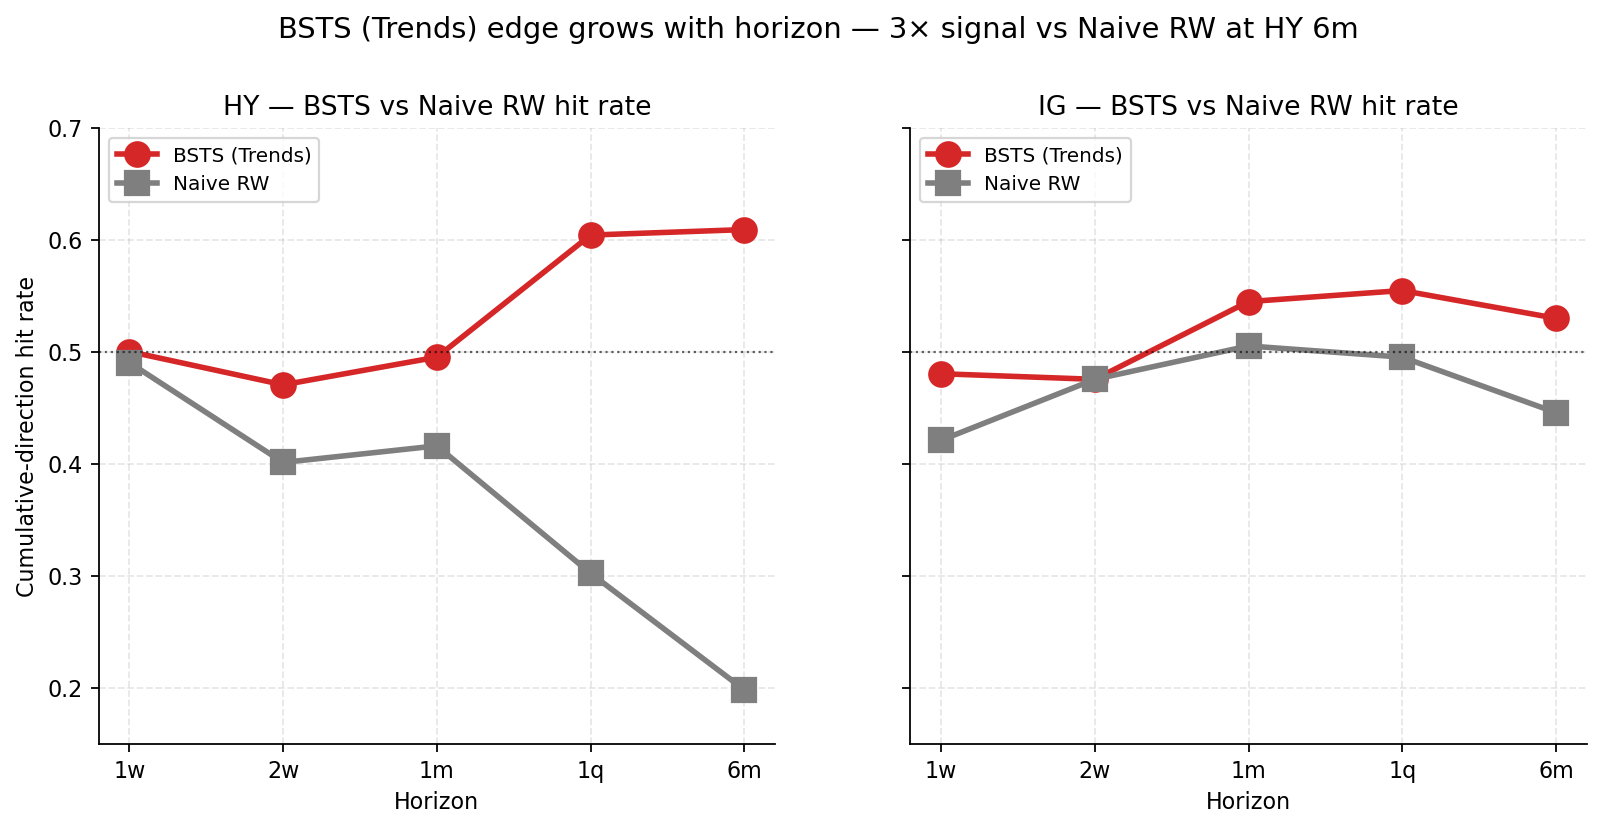

### T1_hit_rate

Cumulative-direction hit rate. Higher = more directional skill.

| target   | model           |    1w |    2w |    1m |    1q |    6m |
|:---------|:----------------|------:|------:|------:|------:|------:|
| HY       | AR(p)           | 0.485 | 0.386 | 0.431 | 0.436 | 0.441 |
| HY       | BSTS (Trends)   | 0.500 | 0.470 | 0.495 | 0.604 | 0.609 |
| HY       | Naive RW        | 0.490 | 0.401 | 0.416 | 0.302 | 0.198 |
| HY       | StackedResidual | 0.530 | 0.406 | 0.525 | 0.475 | 0.376 |
| IG       | AR(p)           | 0.455 | 0.446 | 0.446 | 0.455 | 0.554 |
| IG       | BSTS (Trends)   | 0.480 | 0.475 | 0.545 | 0.554 | 0.530 |
| IG       | Naive RW        | 0.421 | 0.475 | 0.505 | 0.495 | 0.446 |
| IG       | StackedResidual | 0.441 | 0.455 | 0.505 | 0.490 | 0.520 |


In [2]:
display(Image(filename=str(FIG / '03_bsts_vs_rw_hit_rate.png')))
display(Markdown((TBL / 'T1_hit_rate.md').read_text()))

### Per-target hit-rate bars (all 4 models)
Useful when you need the full comparison vs AR(p), StackedResidual, RW side by side.

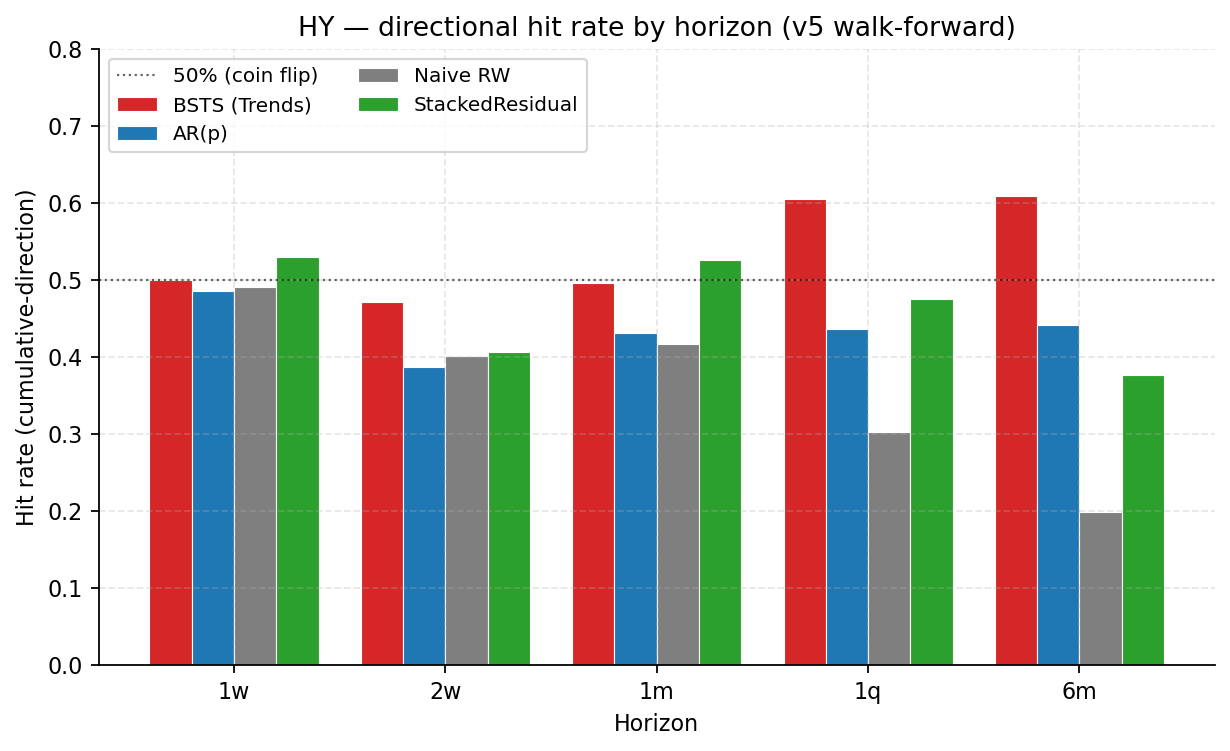

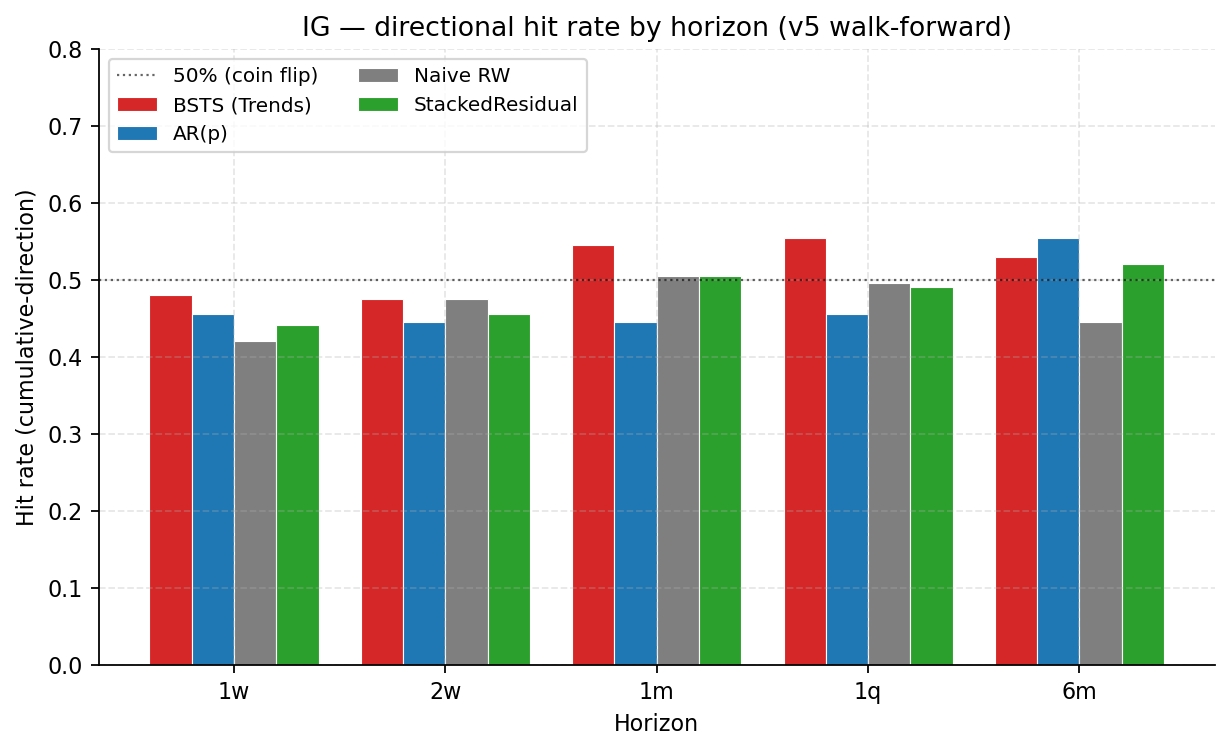

In [3]:
for png in ('01_hit_rate_HY.png', '01_hit_rate_IG.png'):
    display(Image(filename=str(FIG / png)))

---
## 2. Honest RMSE picture

**Slide angle:** *RMSE is a fool's errand on a near-random-walk target — BSTS doesn't
beat AR(4) here, and we report that honestly.* The previous slide is the real story.

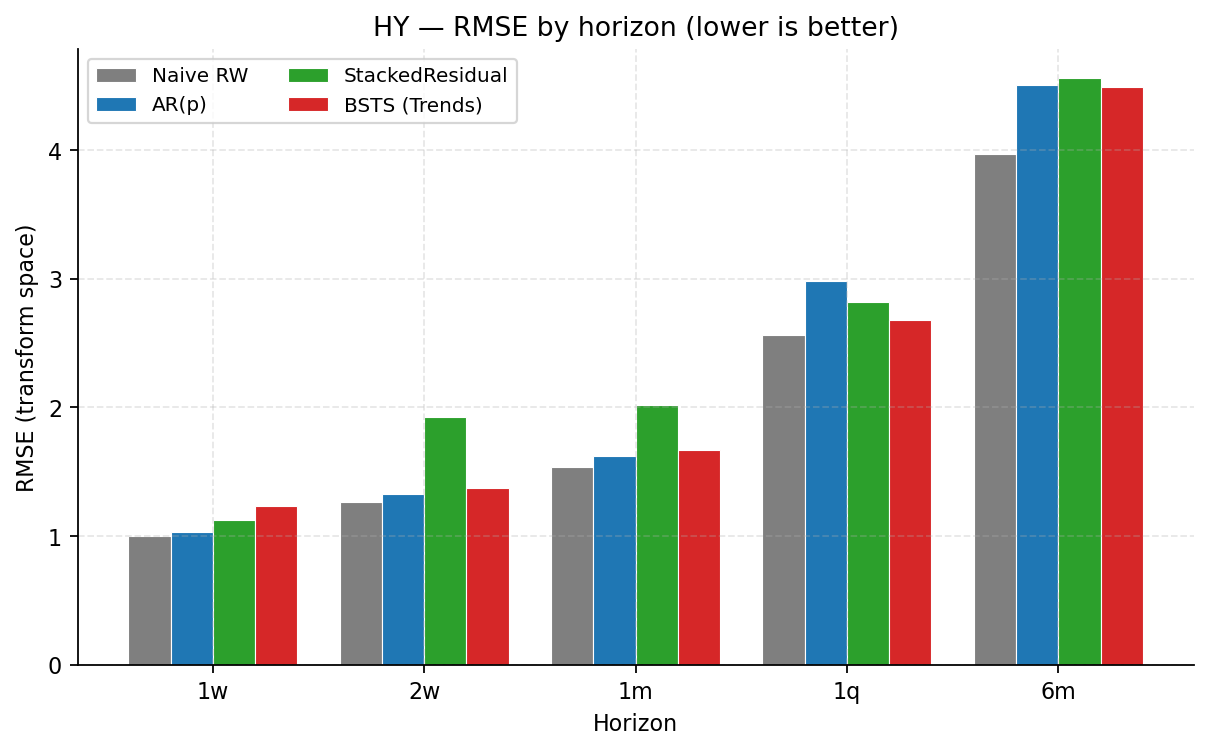

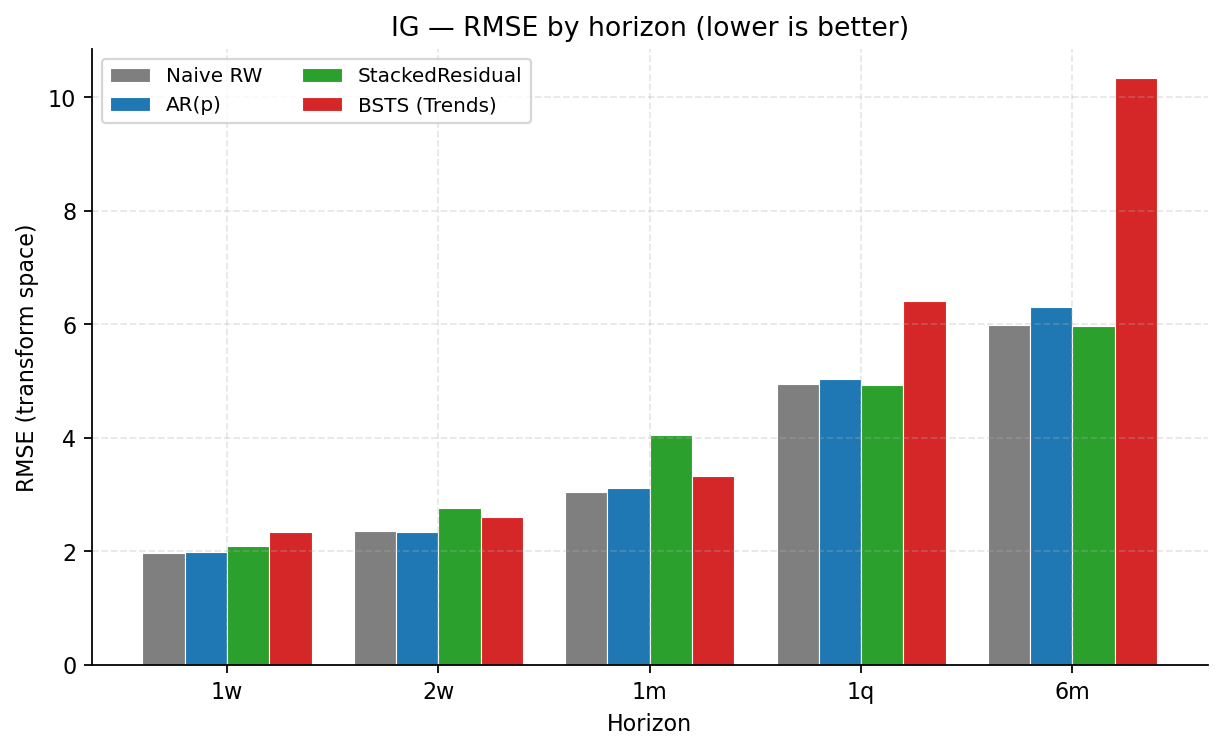

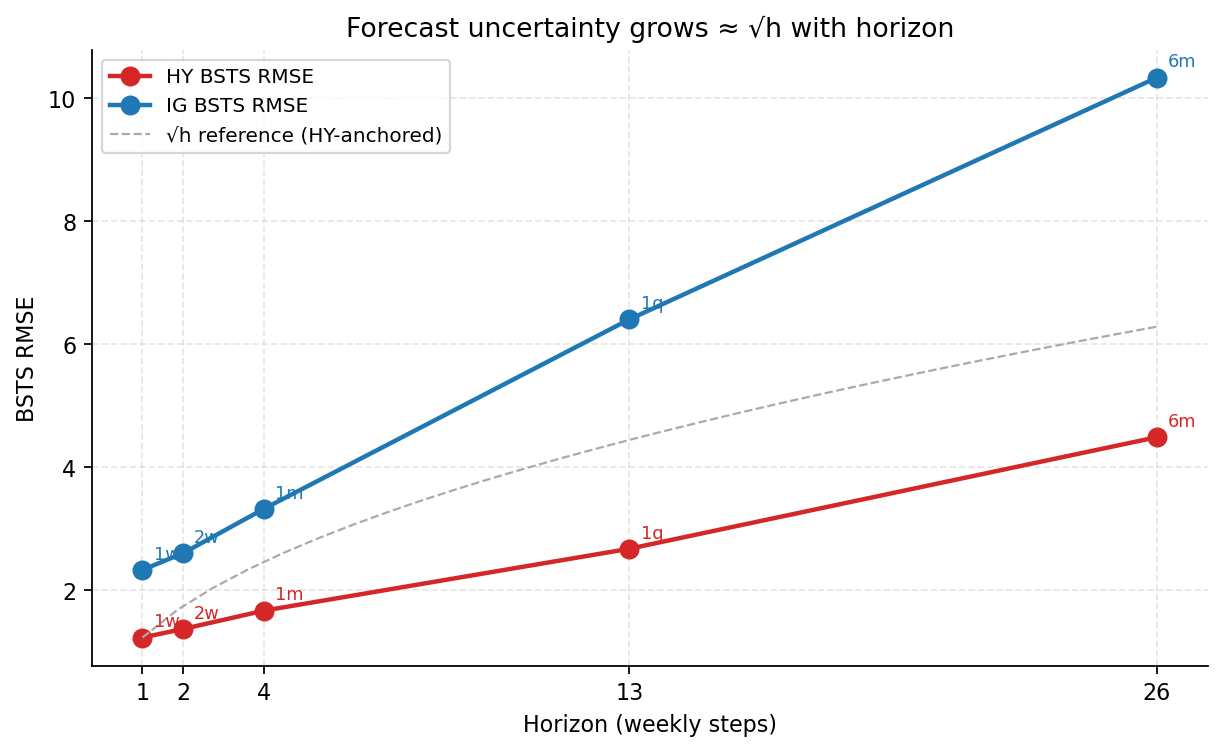

### T2_rmse

RMSE in transform space (level for v5).

| target   | model           |    1w |    2w |    1m |    1q |     6m |
|:---------|:----------------|------:|------:|------:|------:|-------:|
| HY       | AR(p)           | 1.032 | 1.327 | 1.619 | 2.980 |  4.506 |
| HY       | BSTS (Trends)   | 1.233 | 1.372 | 1.672 | 2.677 |  4.491 |
| HY       | Naive RW        | 0.999 | 1.261 | 1.534 | 2.562 |  3.966 |
| HY       | StackedResidual | 1.122 | 1.924 | 2.018 | 2.818 |  4.561 |
| IG       | AR(p)           | 1.981 | 2.344 | 3.110 | 5.026 |  6.301 |
| IG       | BSTS (Trends)   | 2.333 | 2.604 | 3.328 | 6.407 | 10.338 |
| IG       | Naive RW        | 1.958 | 2.348 | 3.044 | 4.950 |  5.977 |
| IG       | StackedResidual | 2.087 | 2.767 | 4.046 | 4.930 |  5.957 |


In [4]:
for png in ('02_rmse_HY.png', '02_rmse_IG.png'):
    display(Image(filename=str(FIG / png)))
display(Image(filename=str(FIG / '09_rmse_vs_horizon.png')))
display(Markdown((TBL / 'T2_rmse.md').read_text()))

---
## 3. What the model is paying attention to

**Slide angle:** *topic predictors (semantic concepts like "Economic crisis",
"Unemployment benefits", "Yield curve") carry the most weight — the v5 upgrade
over v4's categories-only universe.* Signs are economically sensible:
crisis searches up → spread proxy down.

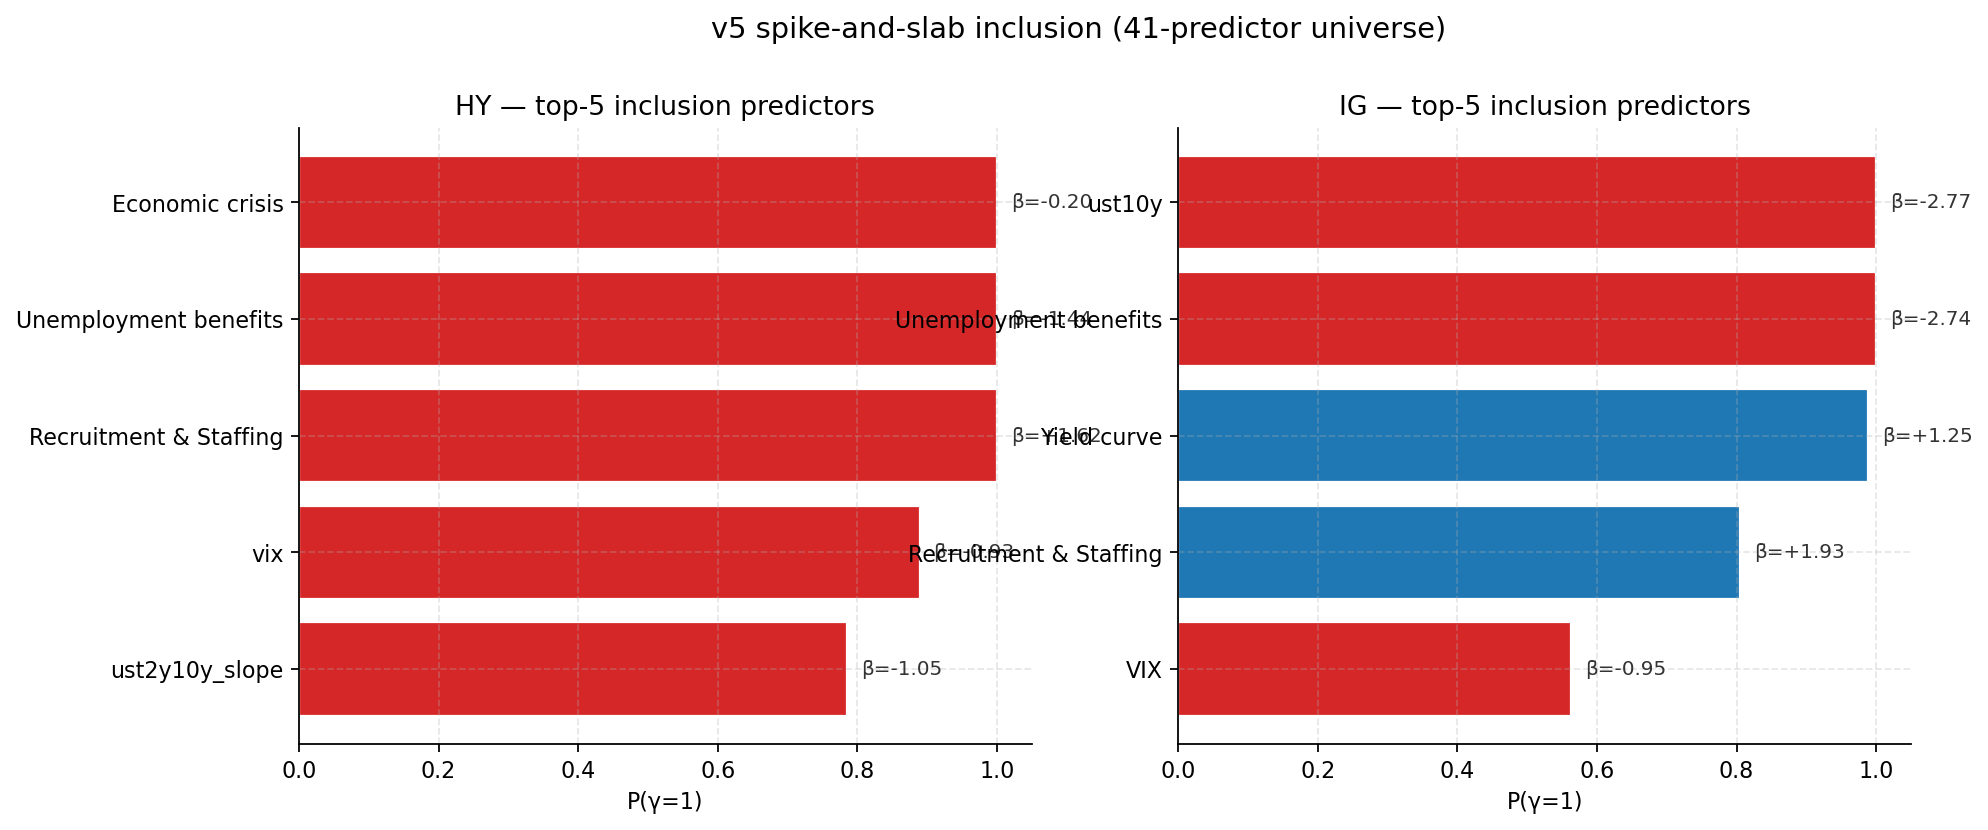

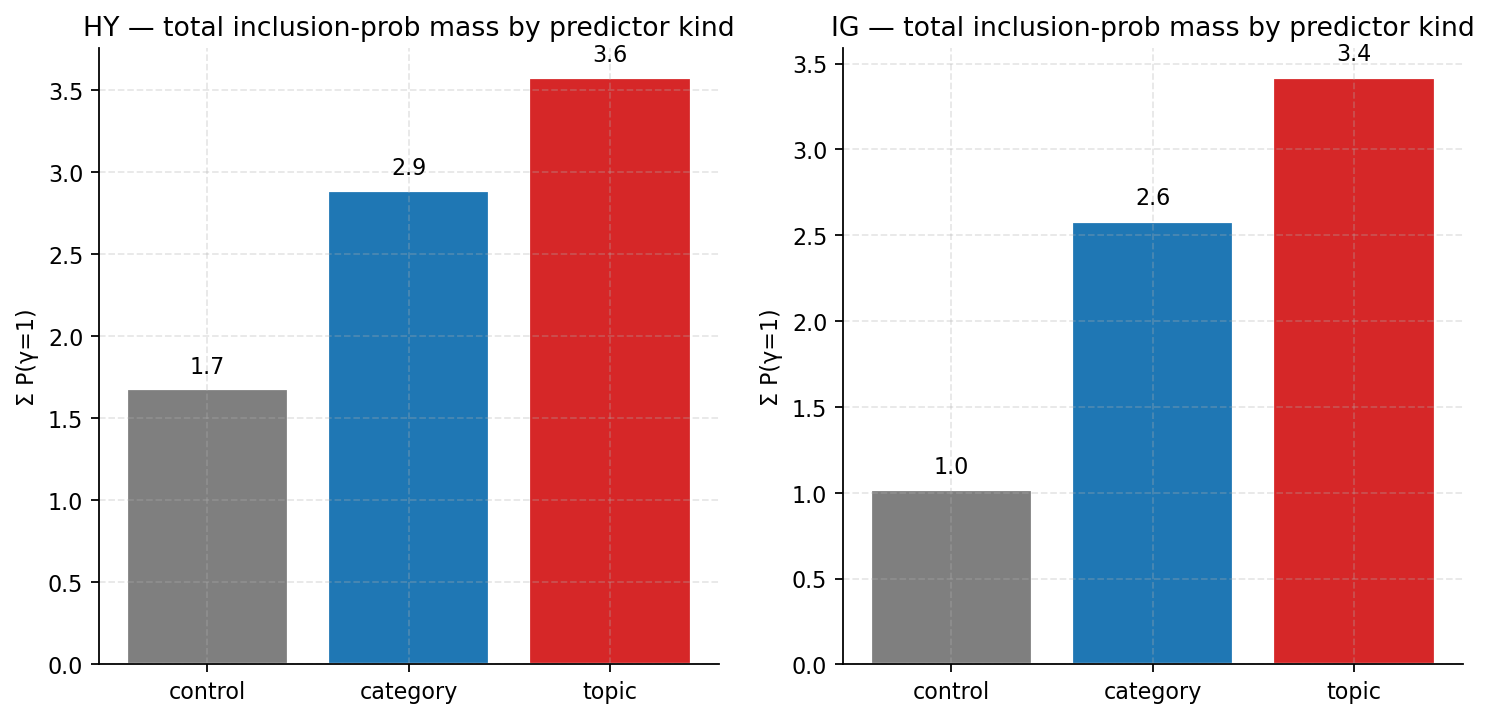

In [5]:
display(Image(filename=str(FIG / '13_top5_inclusion_side_by_side.png')))
display(Image(filename=str(FIG / '11_topic_vs_category_share.png')))

### Full top-15 per target
Use these if the slide needs the deeper list. Bar color encodes sign of β̄.

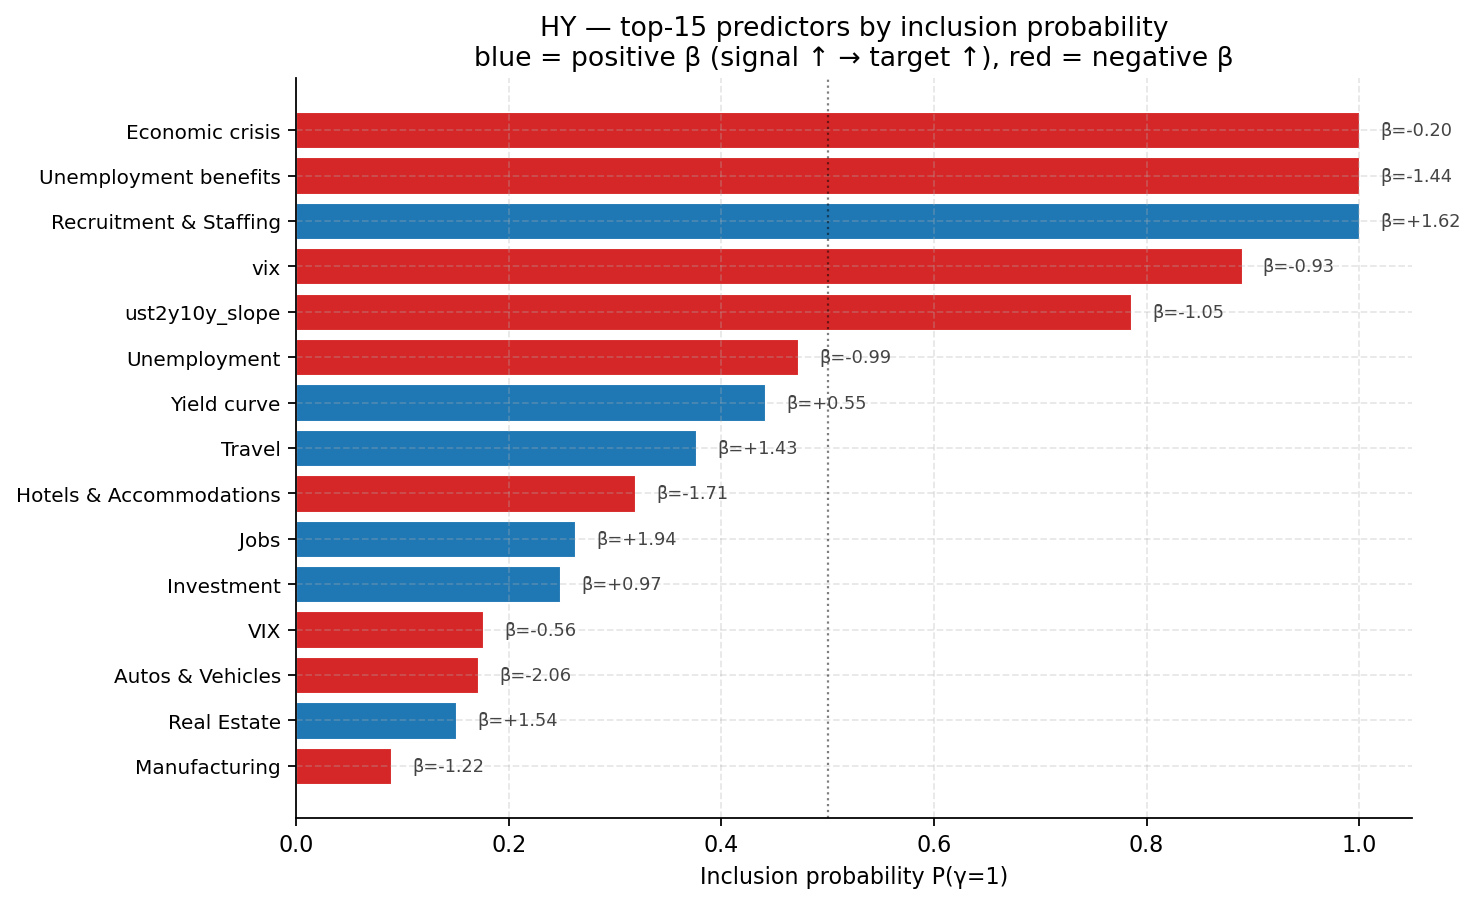

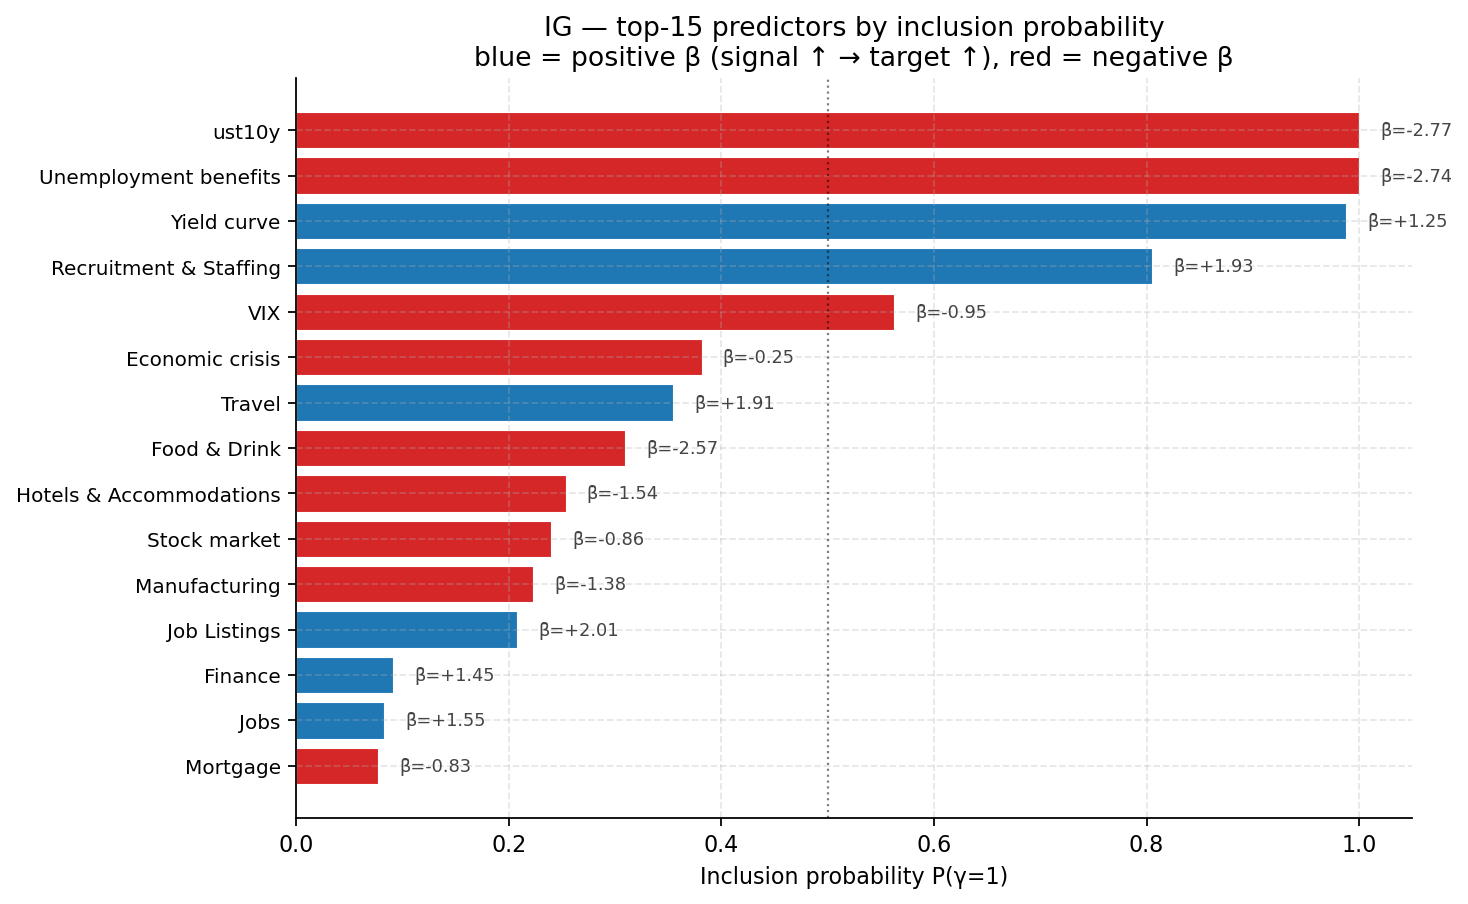

### T5_top_inclusion

Top-10 inclusion predictors per target with sign + consistency.

| target   |   rank | predictor               |   inclusion_prob |   beta_when_included |   sign_consistency |
|:---------|-------:|:------------------------|-----------------:|---------------------:|-------------------:|
| HY       |      1 | Economic crisis         |            1.000 |               -0.199 |              1.000 |
| HY       |      2 | Unemployment benefits   |            1.000 |               -1.445 |              1.000 |
| HY       |      3 | Recruitment & Staffing  |            1.000 |                1.619 |              1.000 |
| HY       |      4 | vix                     |            0.889 |               -0.927 |              1.000 |
| HY       |      5 | ust2y10y_slope          |            0.785 |               -1.051 |              1.000 |
| HY       |      6 | Unemployment            |            0.472 |               -0.994 |              0.994 |
| HY       |      7 | Yield curve             |            0.441 |                0.552 |              1.000 |
| HY       |      8 | Travel                  |            0.376 |                1.433 |              0.979 |
| HY       |      9 | Hotels & Accommodations |            0.319 |               -1.712 |              0.996 |
| HY       |     10 | Jobs                    |            0.263 |                1.944 |              0.970 |
| IG       |      1 | ust10y                  |            1.000 |               -2.770 |              1.000 |
| IG       |      2 | Unemployment benefits   |            1.000 |               -2.741 |              1.000 |
| IG       |      3 | Yield curve             |            0.988 |                1.249 |              1.000 |
| IG       |      4 | Recruitment & Staffing  |            0.805 |                1.926 |              1.000 |
| IG       |      5 | VIX                     |            0.563 |               -0.951 |              1.000 |
| IG       |      6 | Economic crisis         |            0.381 |               -0.250 |              1.000 |
| IG       |      7 | Travel                  |            0.355 |                1.907 |              0.940 |
| IG       |      8 | Food & Drink            |            0.309 |               -2.572 |              0.961 |
| IG       |      9 | Hotels & Accommodations |            0.253 |               -1.541 |              0.984 |
| IG       |     10 | Stock market            |            0.240 |               -0.857 |              0.994 |


In [6]:
for png in ('04_inclusion_HY.png', '04_inclusion_IG.png'):
    display(Image(filename=str(FIG / png)))
display(Markdown((TBL / 'T5_top_inclusion.md').read_text()))

---
## 4. Trends Risk Index — the PM-headline artifact

**Slide angle:** *the inclusion-weighted z-score of Trends signal spikes around
credit-stress episodes (COVID, Lehman) and stays muted in benign regimes.*
Weekly cadence is the PM-facing default; daily is a watchlist visualization.

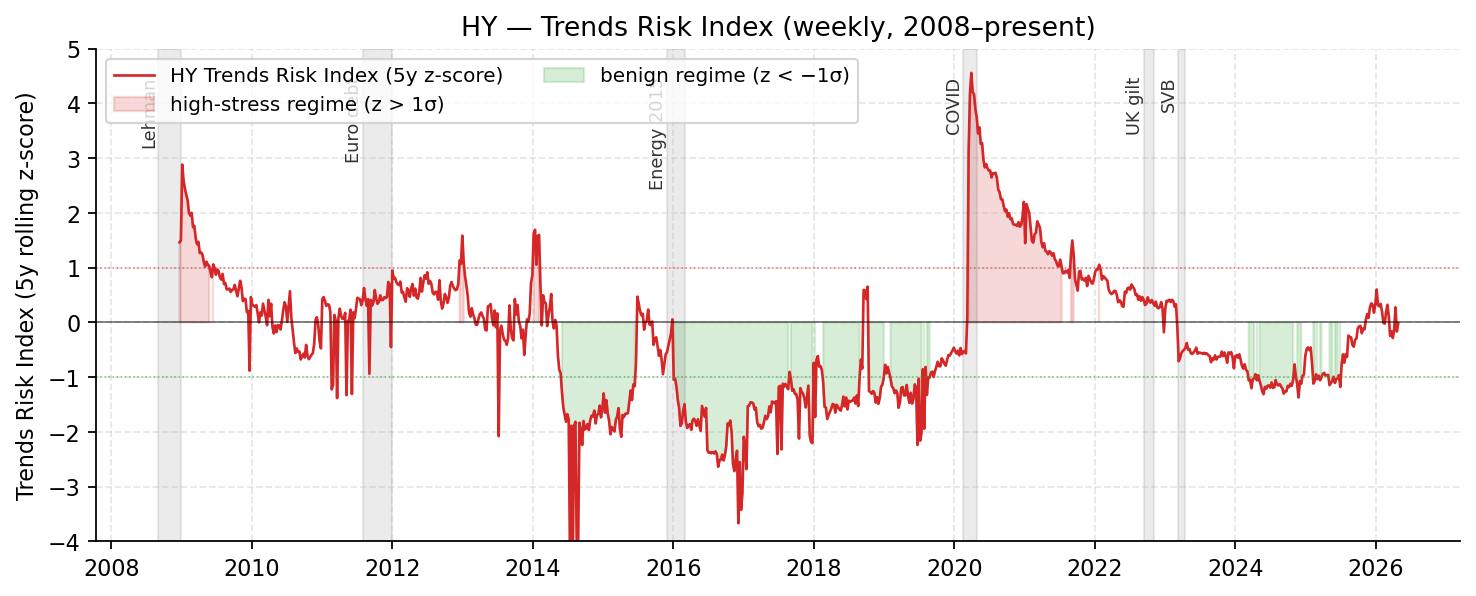

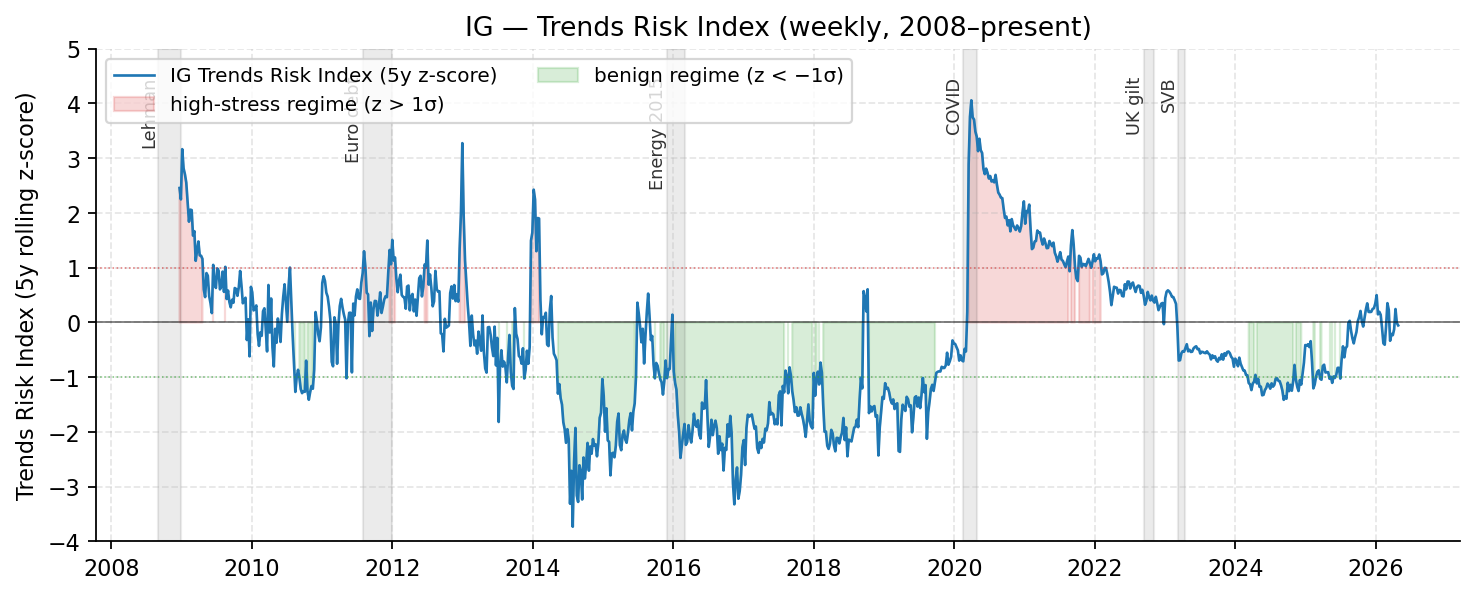

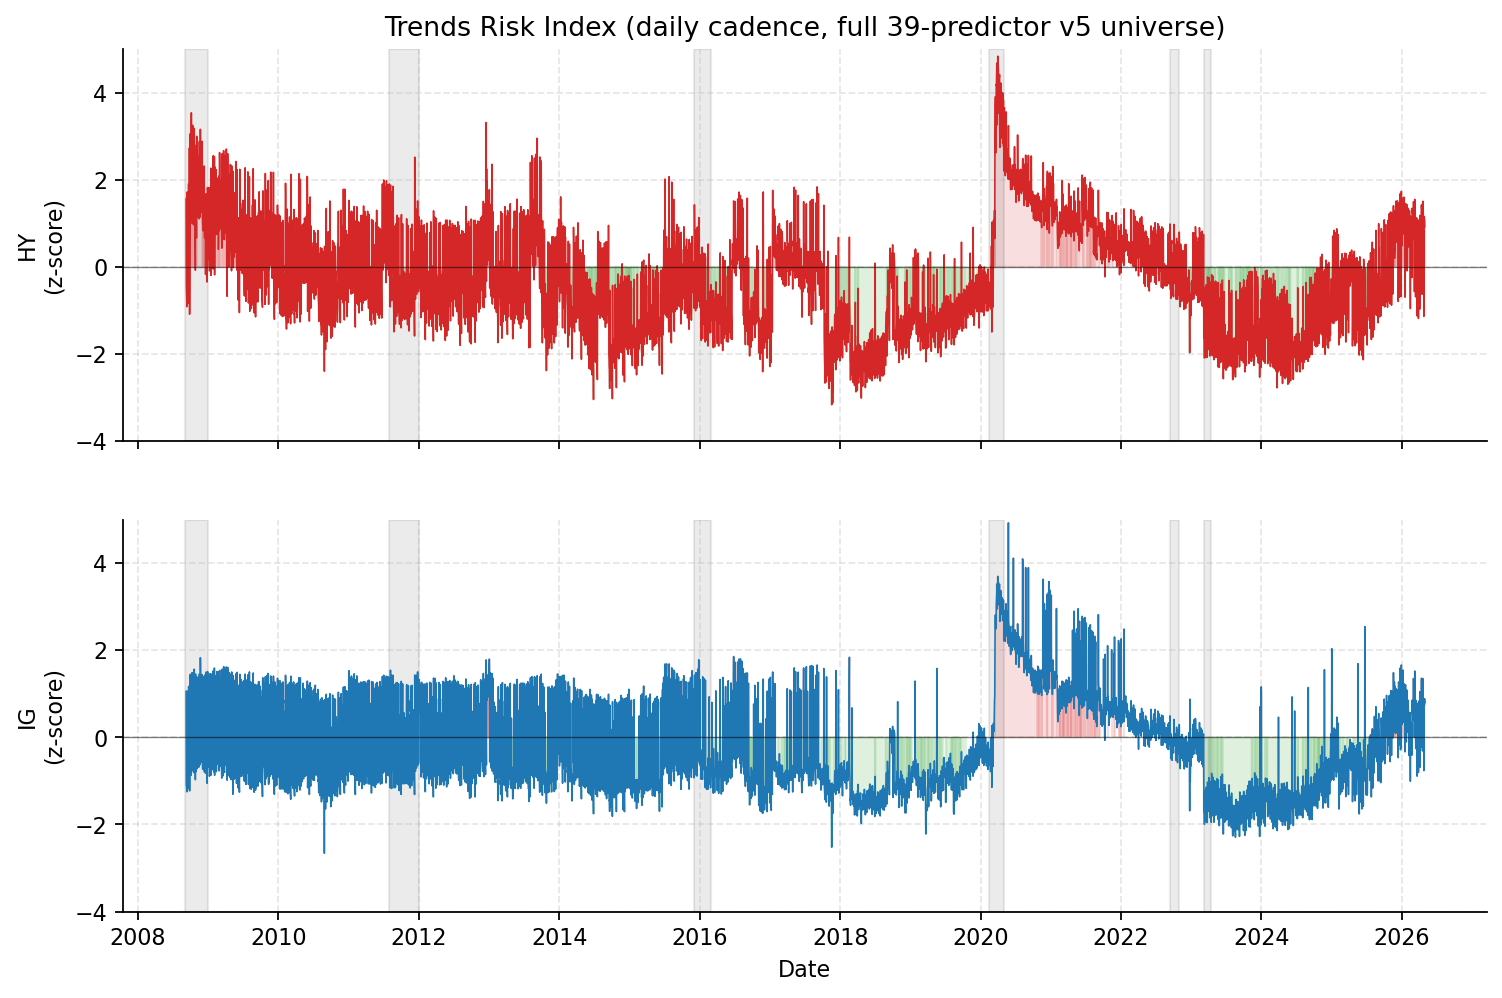

### T4_granger

Granger causality of Trends Risk Index over Δlog(target), controlling for ΔVIX.

| cadence   | target   |   F_stat |   p_value |   delta_R2 | significant_at_0.05   |
|:----------|:---------|---------:|----------:|-----------:|:----------------------|
| weekly    | HY       |    1.713 |     0.145 |      0.007 | ✗                     |
| weekly    | IG       |    3.791 |     0.005 |      0.016 | ✓                     |
| daily     | HY       |    0.409 |     0.802 |      0.000 | ✗                     |
| daily     | IG       |    0.556 |     0.695 |      0.001 | ✗                     |


Granger note: weekly IG retains v4-level significance (p=0.005). Daily IG lost significance with the wider v5 predictor universe (more high-frequency idiosyncratic noise dilutes the daily signal) — flagged in `SUBMISSION_SUMMARY.md` caveat #3.

In [7]:
for png in ('05_risk_index_weekly_HY.png', '05_risk_index_weekly_IG.png'):
    display(Image(filename=str(FIG / png)))
display(Image(filename=str(FIG / '06_risk_index_daily.png')))
display(Markdown((TBL / 'T4_granger.md').read_text()))
display(Markdown(
    'Granger note: weekly IG retains v4-level significance (p=0.005). '
    'Daily IG lost significance with the wider v5 predictor universe '
    '(more high-frequency idiosyncratic noise dilutes the daily signal) — '
    'flagged in `SUBMISSION_SUMMARY.md` caveat #3.'
))

---
## 5. Calibration — credible bands actually contain truth at the right rate

**Slide angle:** *conformal recalibration lands all 8 cells in the
in-sample acceptance band [0.75, 0.85] around 80% nominal coverage.*
Numbers under each bar are the per-cell α multiplier.

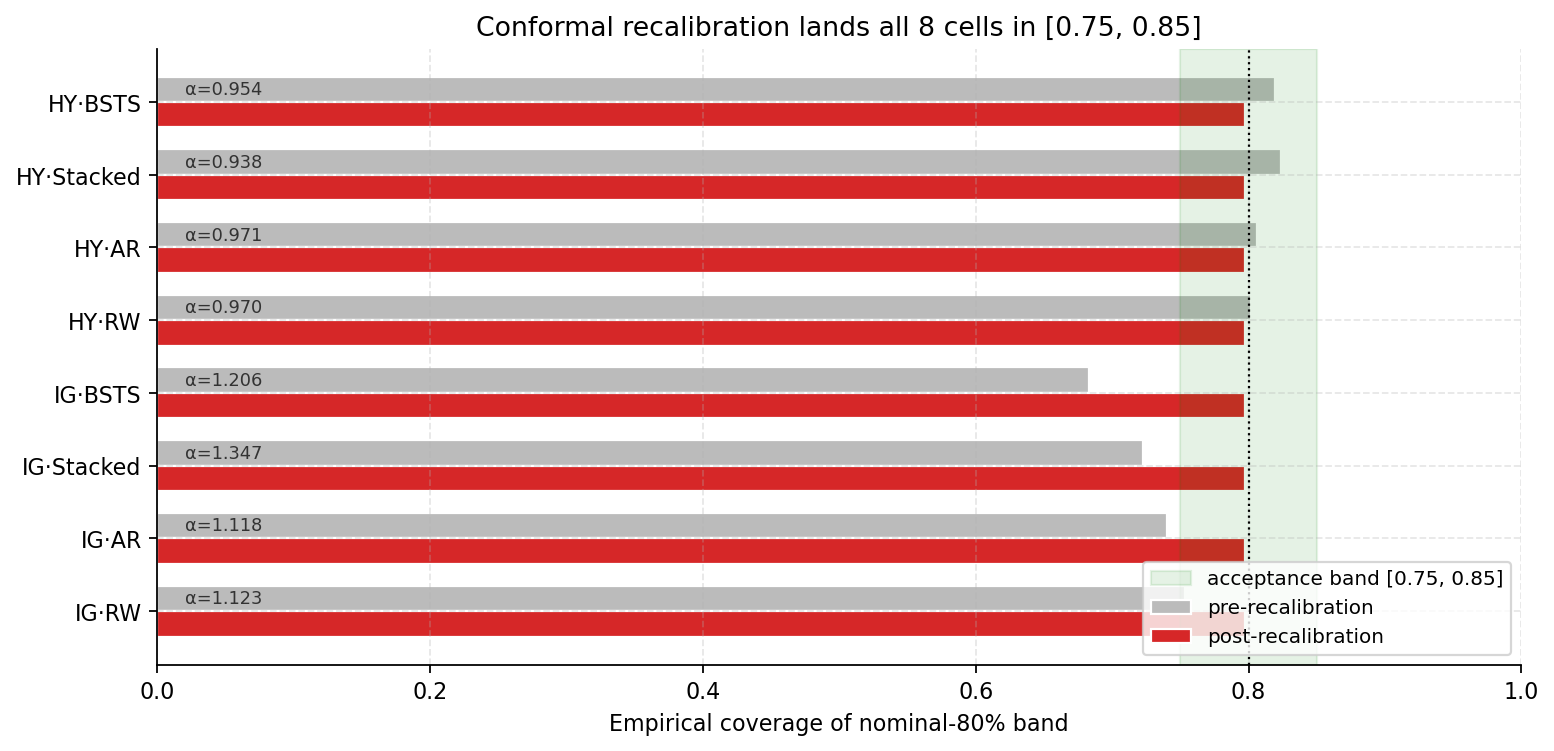

### T3_calibration

Conformal recalibration: 8/8 cells land in [0.75, 0.85].

| target   | model           |   alpha |   pre_cov_80 |   post_cov_80 | in_band   |
|:---------|:----------------|--------:|-------------:|--------------:|:----------|
| HY       | BSTS (Trends)   |   0.954 |        0.819 |         0.797 | ✓         |
| HY       | StackedResidual |   0.938 |        0.824 |         0.797 | ✓         |
| HY       | AR(p)           |   0.971 |        0.806 |         0.797 | ✓         |
| HY       | Naive RW        |   0.970 |        0.802 |         0.797 | ✓         |
| IG       | BSTS (Trends)   |   1.206 |        0.683 |         0.797 | ✓         |
| IG       | StackedResidual |   1.347 |        0.722 |         0.797 | ✓         |
| IG       | AR(p)           |   1.118 |        0.740 |         0.797 | ✓         |
| IG       | Naive RW        |   1.123 |        0.753 |         0.797 | ✓         |


In [8]:
display(Image(filename=str(FIG / '07_calibration_coverage.png')))
display(Markdown((TBL / 'T3_calibration.md').read_text()))

---
## 6. Forward-looking forecast (the "what does it say now?" slide)

**Slide angle:** *here is the model's view today, with a 90% band scaled by α.*
Median + band for each PM horizon (1w / 2w / 1m / 1q / 6m). Band width grows
≈ √h with horizon — exactly what you expect from near-random-walk dynamics.

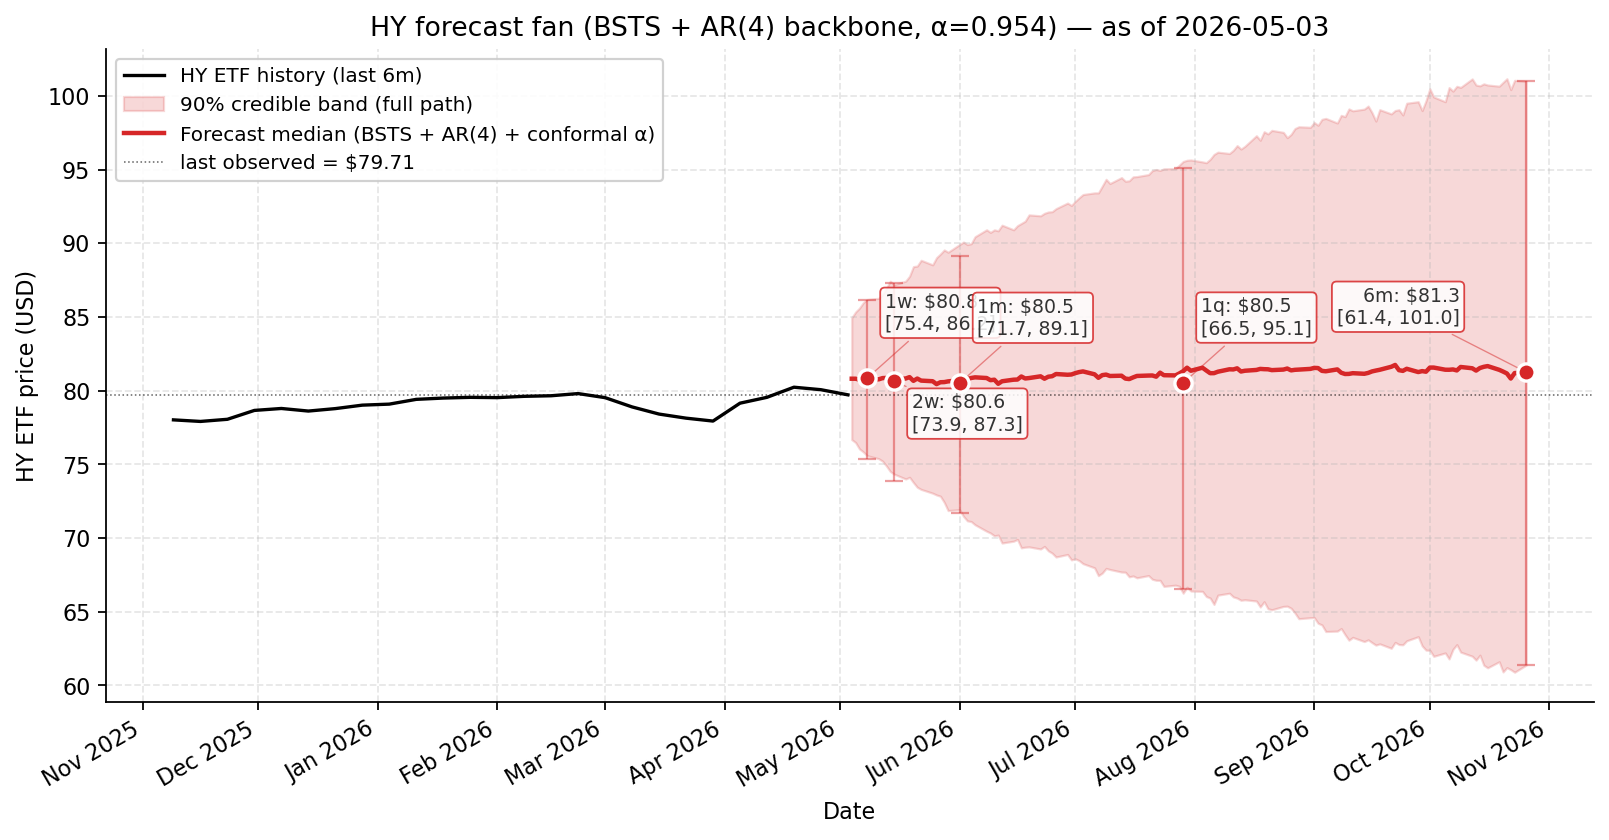

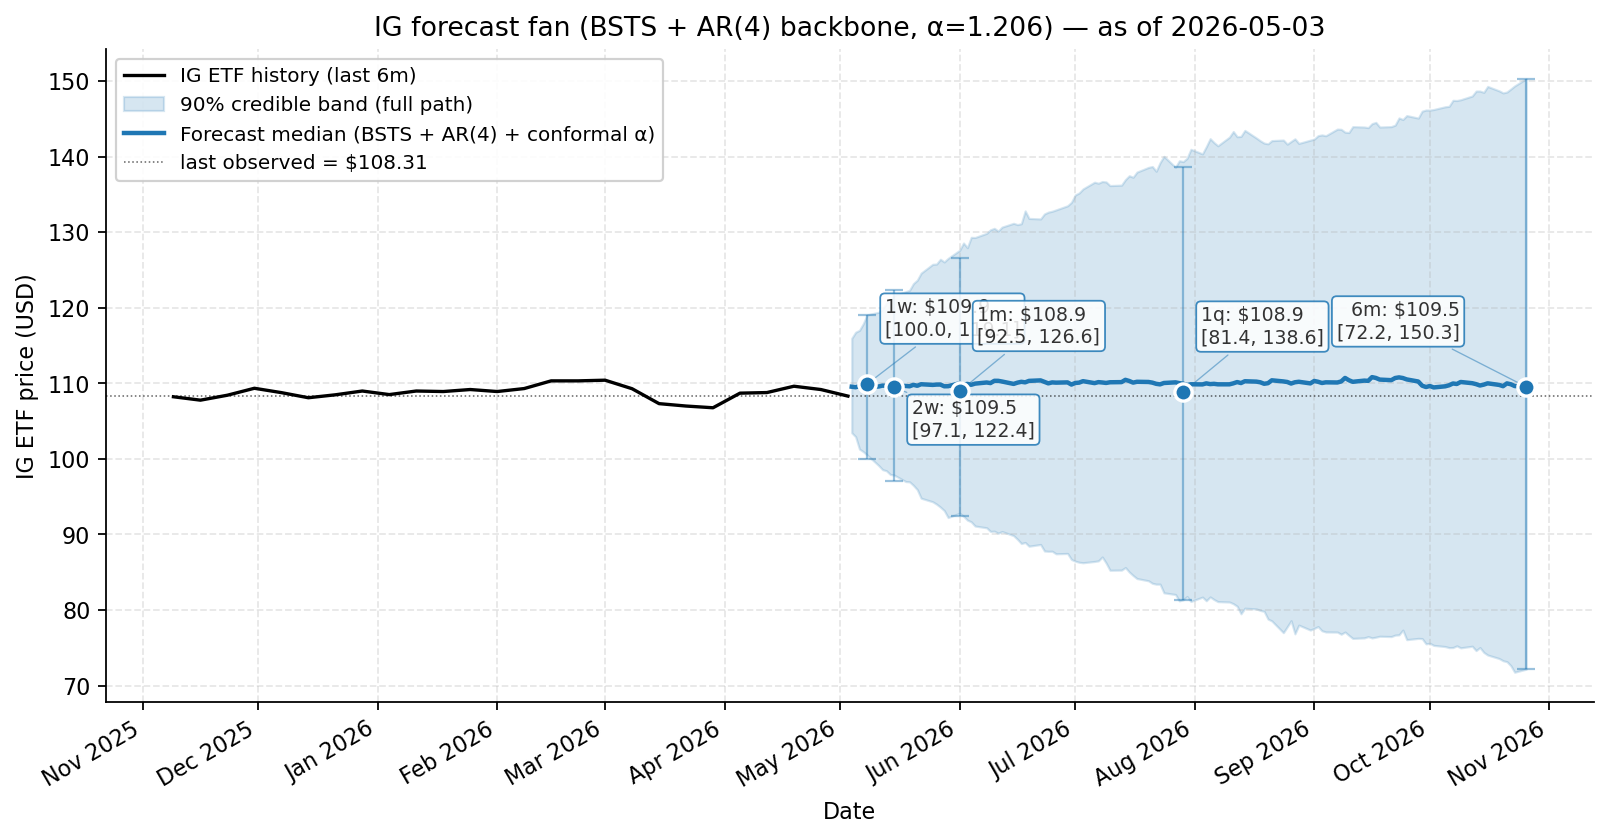

In [9]:
for png in ('08_forecast_fan_HY.png', '08_forecast_fan_IG.png'):
    display(Image(filename=str(FIG / png)))

---
## 7. In-sample sanity — "what does the 1-week forecast actually look like over time?"

**Slide angle:** *near-RW behavior at 1w is unavoidable; the BSTS adds short-term
tracking noise that gets paid back at long horizons.* Use this as honest backup
if anyone challenges the RMSE table.

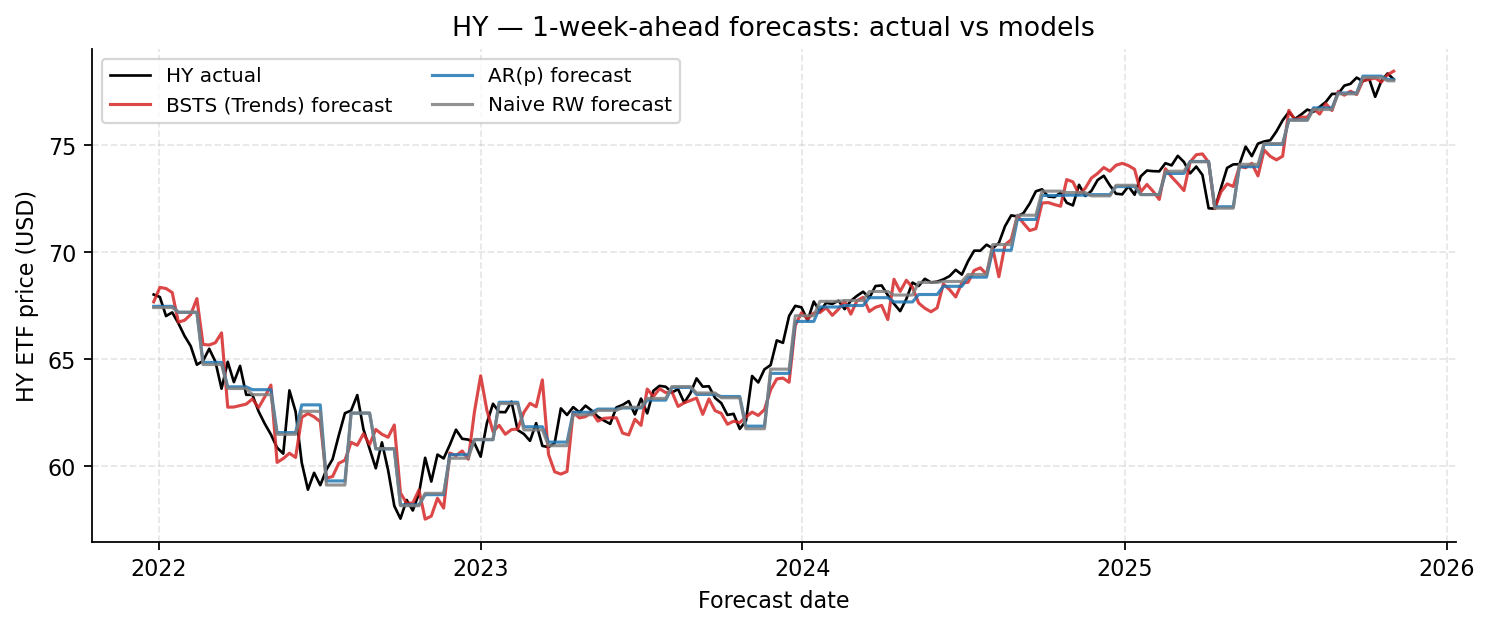

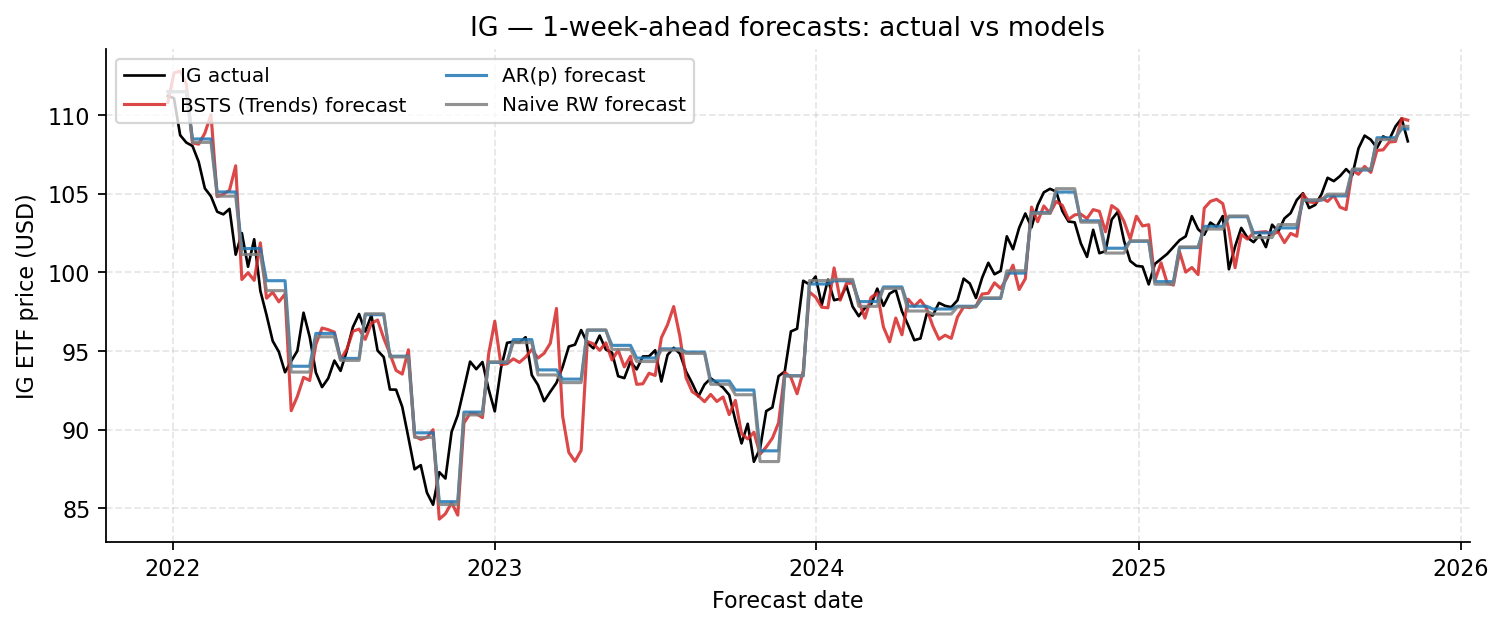

In [10]:
for png in ('12_forecast_vs_baselines_HY.png', '12_forecast_vs_baselines_IG.png'):
    display(Image(filename=str(FIG / png)))

---
## 8. Caveat slide — ETF proxy quality

**Slide angle:** *honest reporting. We train on HYG / LQD ETFs as proxies for
HY / IG OAS. HY proxy quality is defensible (Pearson −0.69 vs ΔOAS); IG is
weak (−0.24) because LQD carries duration noise the Trends predictors don't
directly model. Read IG forecasts with extra grain-of-salt.*

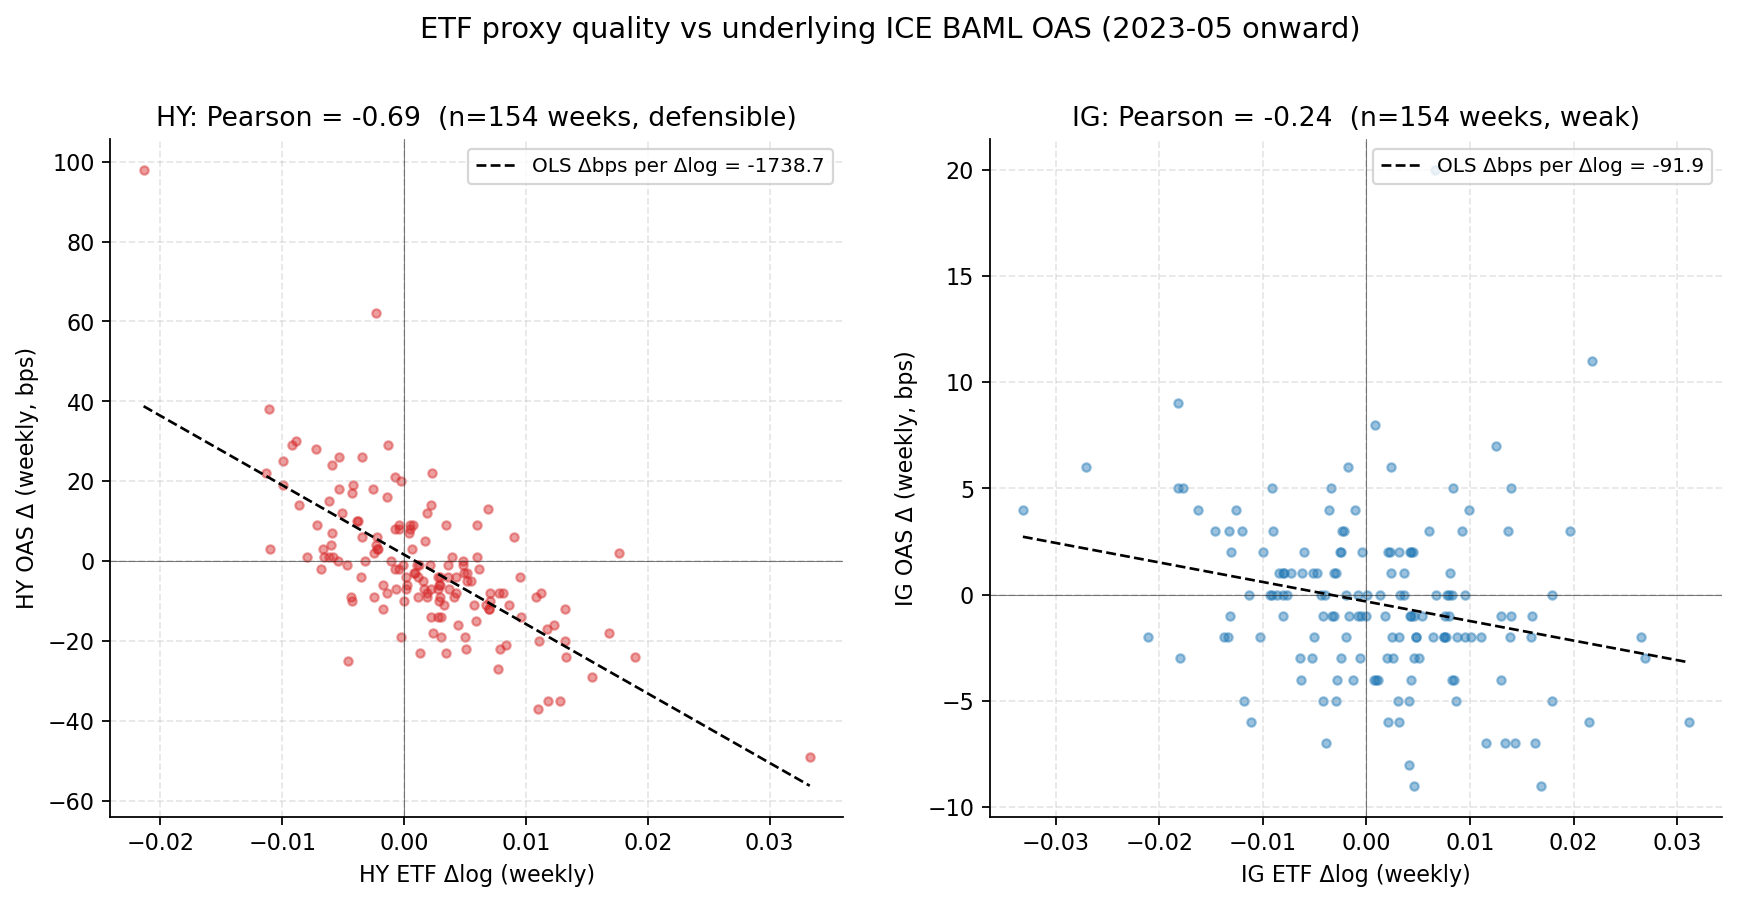

In [11]:
display(Image(filename=str(FIG / '10_oas_proxy_scatter.png')))

---
## 9. Direct OAS forecast — bps in, bps out

**Slide angle:** *for the PM-headline question "where is the OAS spread headed?", v5 ships two independent answers.* The ETF model gets translated to OAS bps via the empirical FRED-overlap regression (fig 14). The v5.1 OAS-direct BSTS — trained directly on the 154-week FRED OAS history — produces an independent bps forecast for comparison (fig 15). Disagreement between the two is honest model-uncertainty signal.

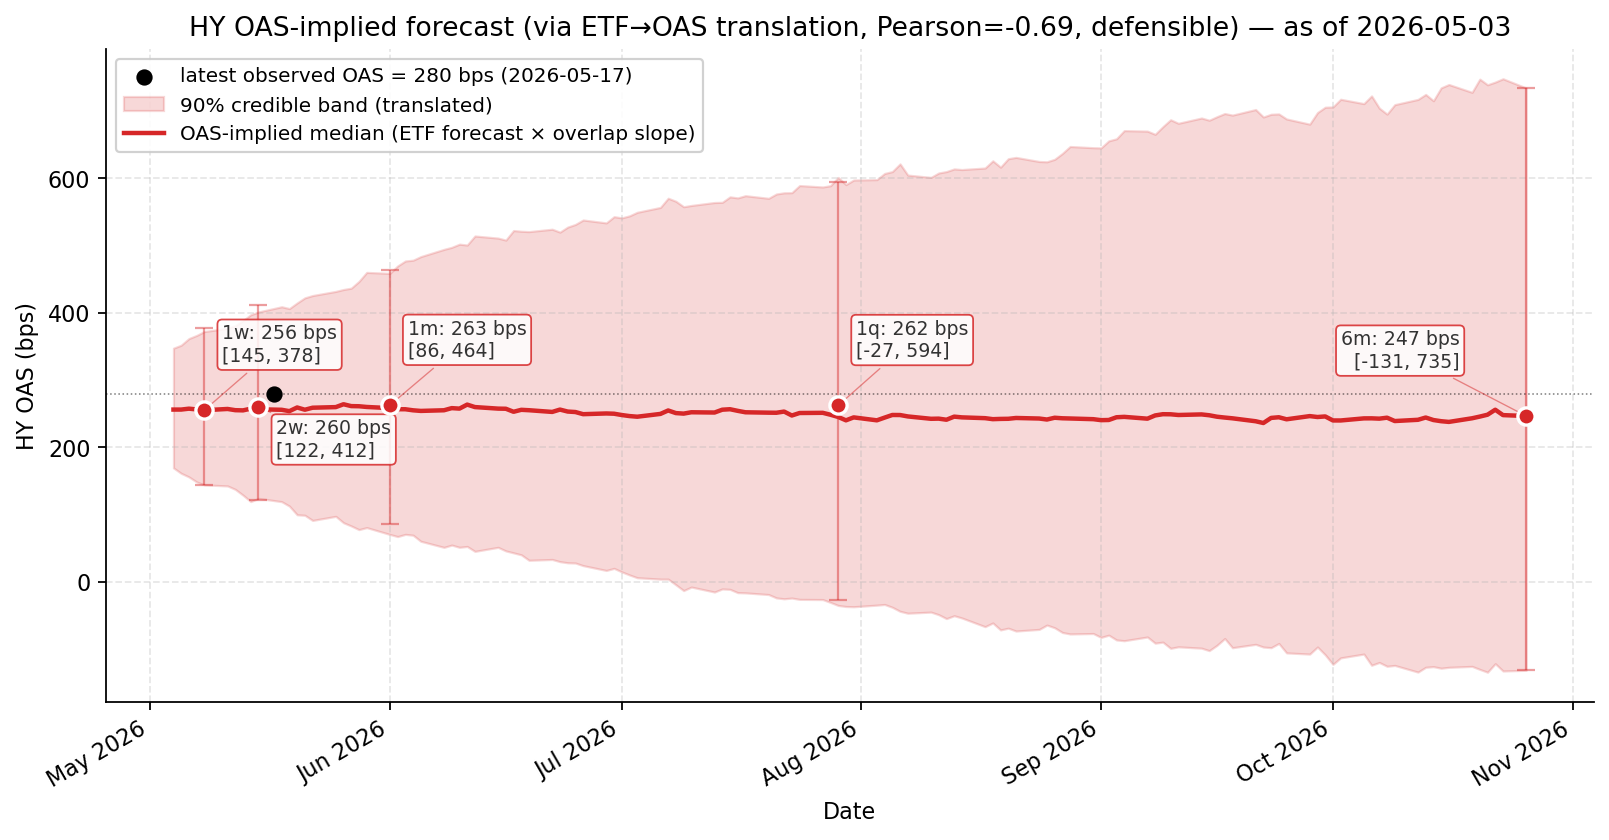

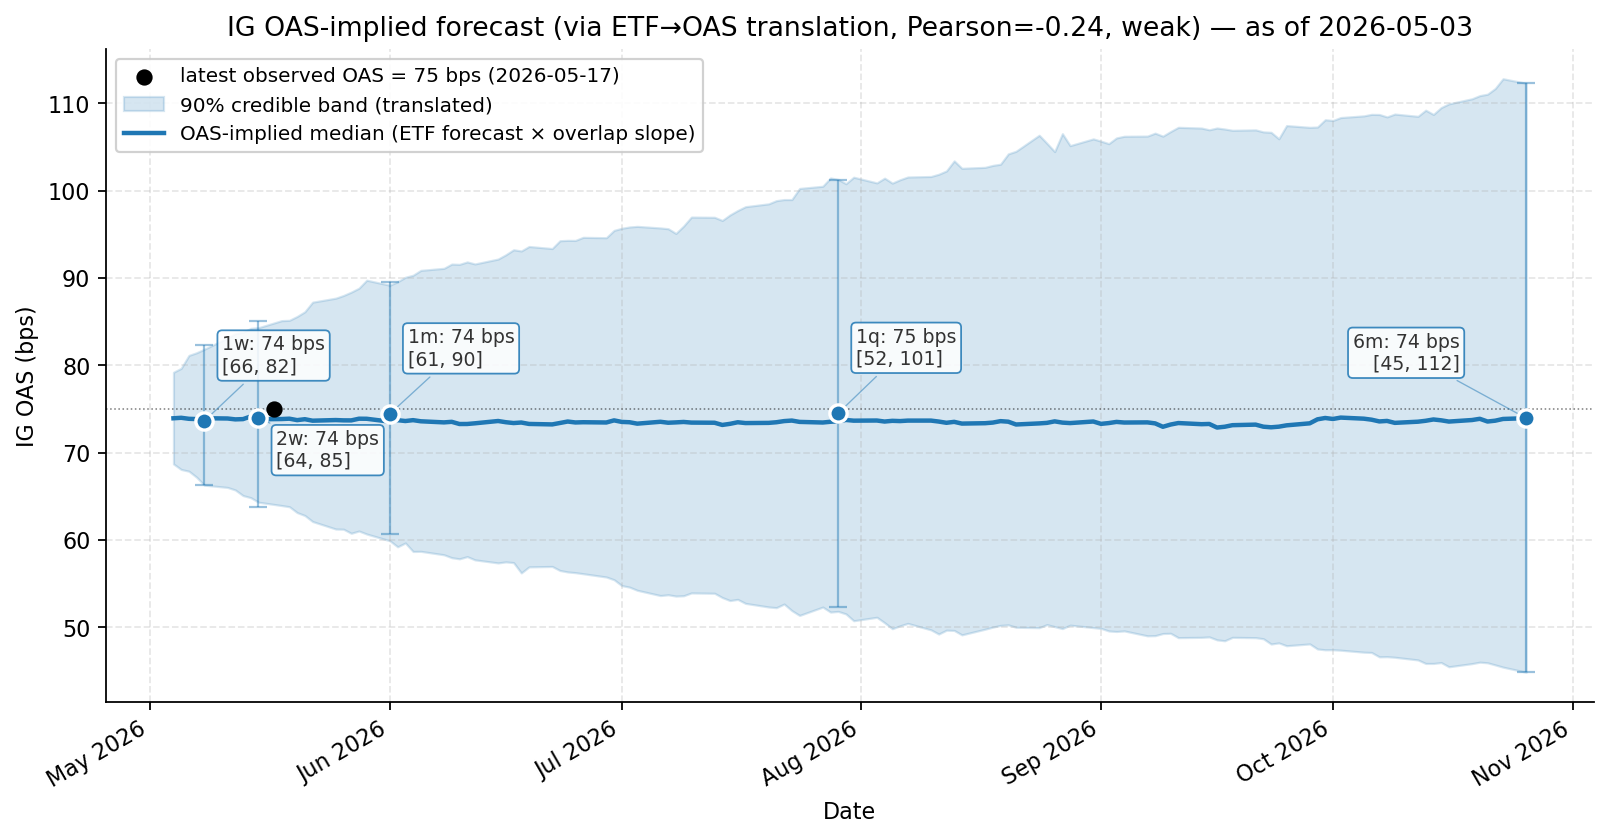

### T6_oas_translation

ETF→OAS translation provenance: regression slope, Pearson, n_overlap_weeks, latest OAS anchor.

| target   |   slope_bps_per_dlog |   pearson |   spearman |   n_overlap_weeks |   last_oas_bps | last_oas_date   | proxy_quality   |
|:---------|---------------------:|----------:|-----------:|------------------:|---------------:|:----------------|:----------------|
| HY       |            -1738.740 |    -0.691 |     -0.665 |               154 |        280.000 | 2026-05-17      | defensible      |
| IG       |              -91.930 |    -0.241 |     -0.269 |               154 |         75.000 | 2026-05-17      | weak            |


In [12]:
# OAS-implied fan (ETF model translated into bps).
for png in ('14_oas_implied_fan_HY.png', '14_oas_implied_fan_IG.png'):
    display(Image(filename=str(FIG / png)))
display(Markdown((TBL / 'T6_oas_translation.md').read_text()))

### Direct vs implied — honest model disagreement

Each horizon: red dot = OAS-direct BSTS forecast (small-N, 154-week
history), gray square = OAS-implied translation from the ETF model. When
they agree, conviction is higher. When they disagree, the disagreement
magnitude is the PM's regime-uncertainty gauge.

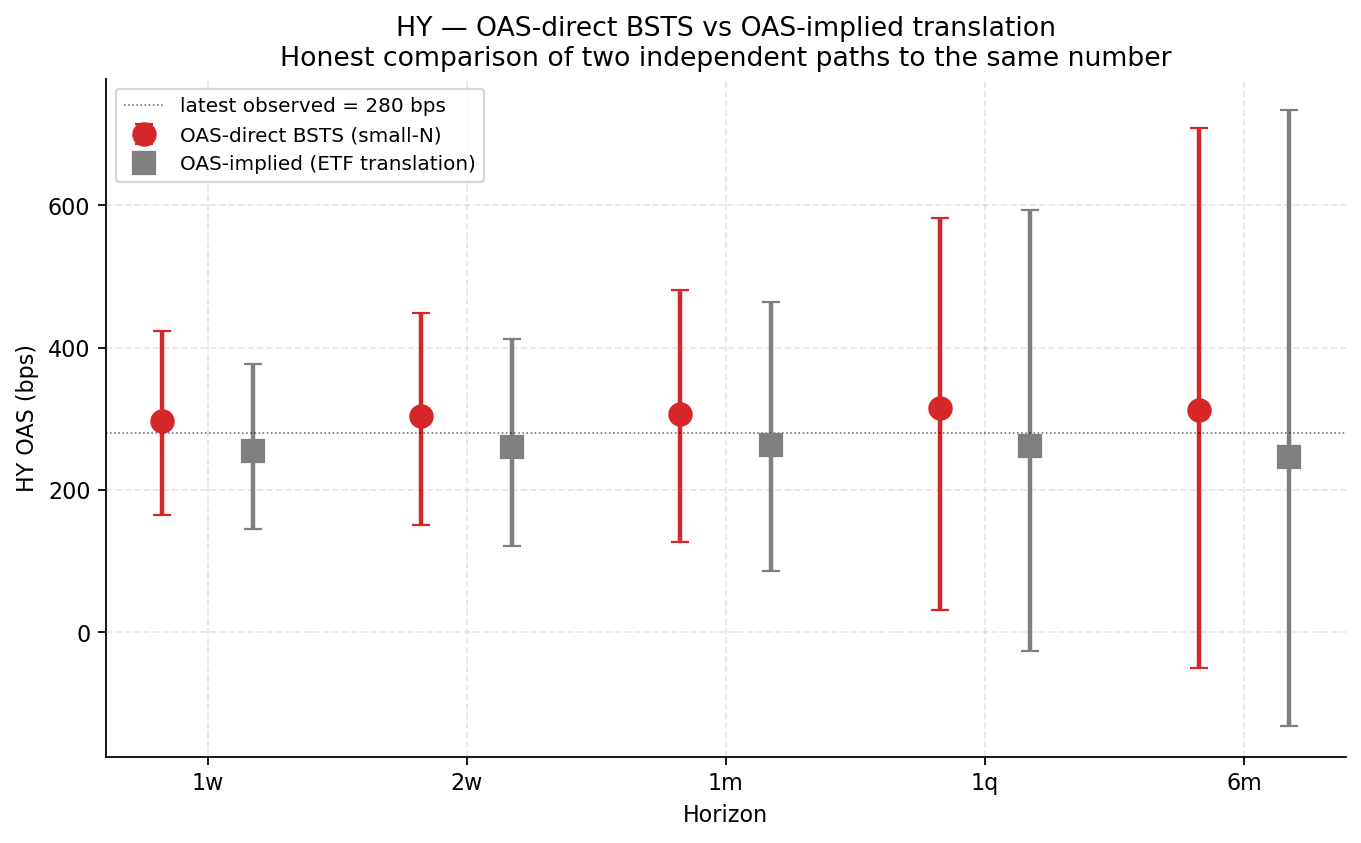

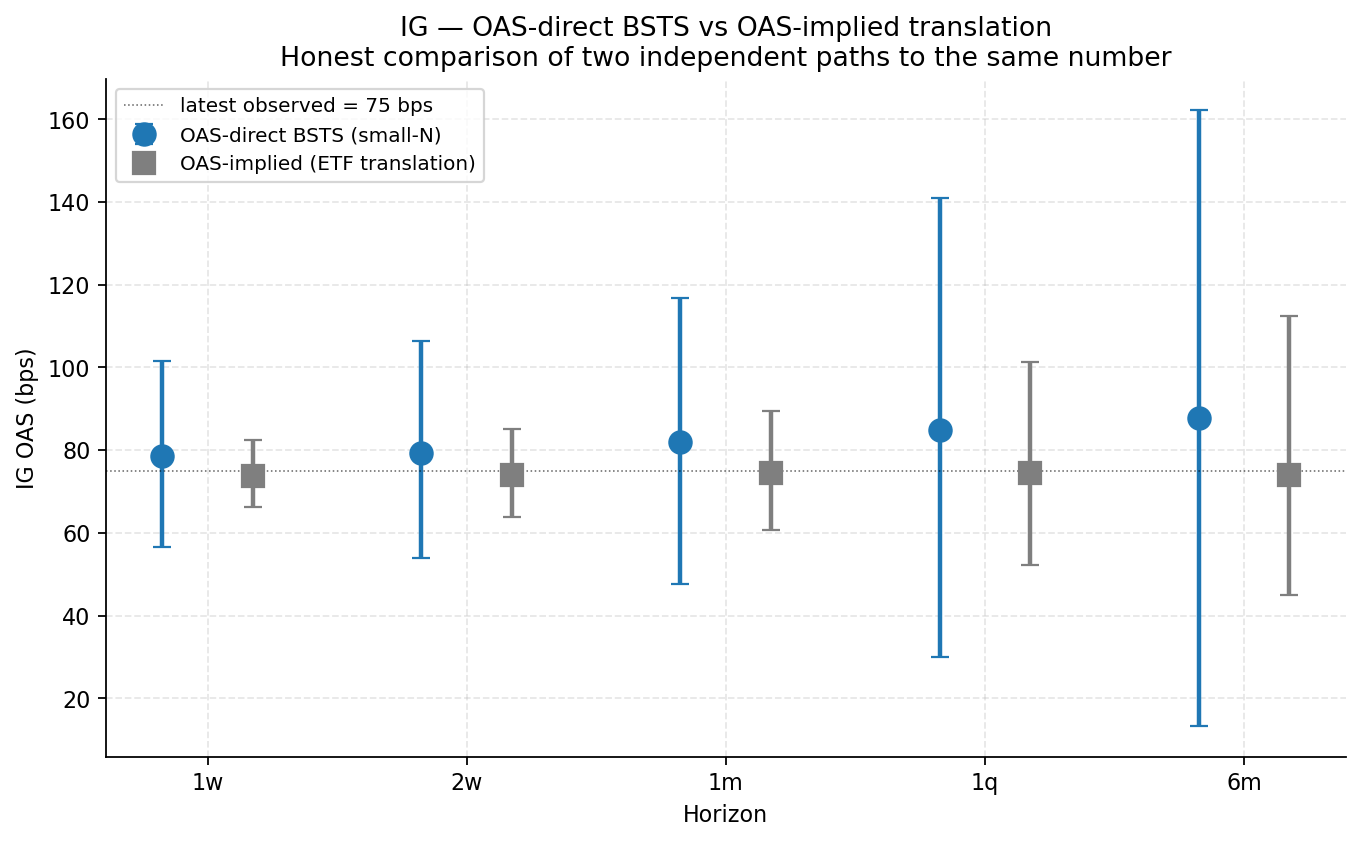

In [13]:
for png in ('15_oas_direct_vs_implied_HY.png', '15_oas_direct_vs_implied_IG.png'):
    display(Image(filename=str(FIG / png)))

### Where are we headed — 3-year history + current forecast

The "now-cast" view: 3 years of actual OAS bps with the OAS-direct
BSTS forecast band tacked onto the right. Useful as a single "this is
where the model thinks spreads go" slide.

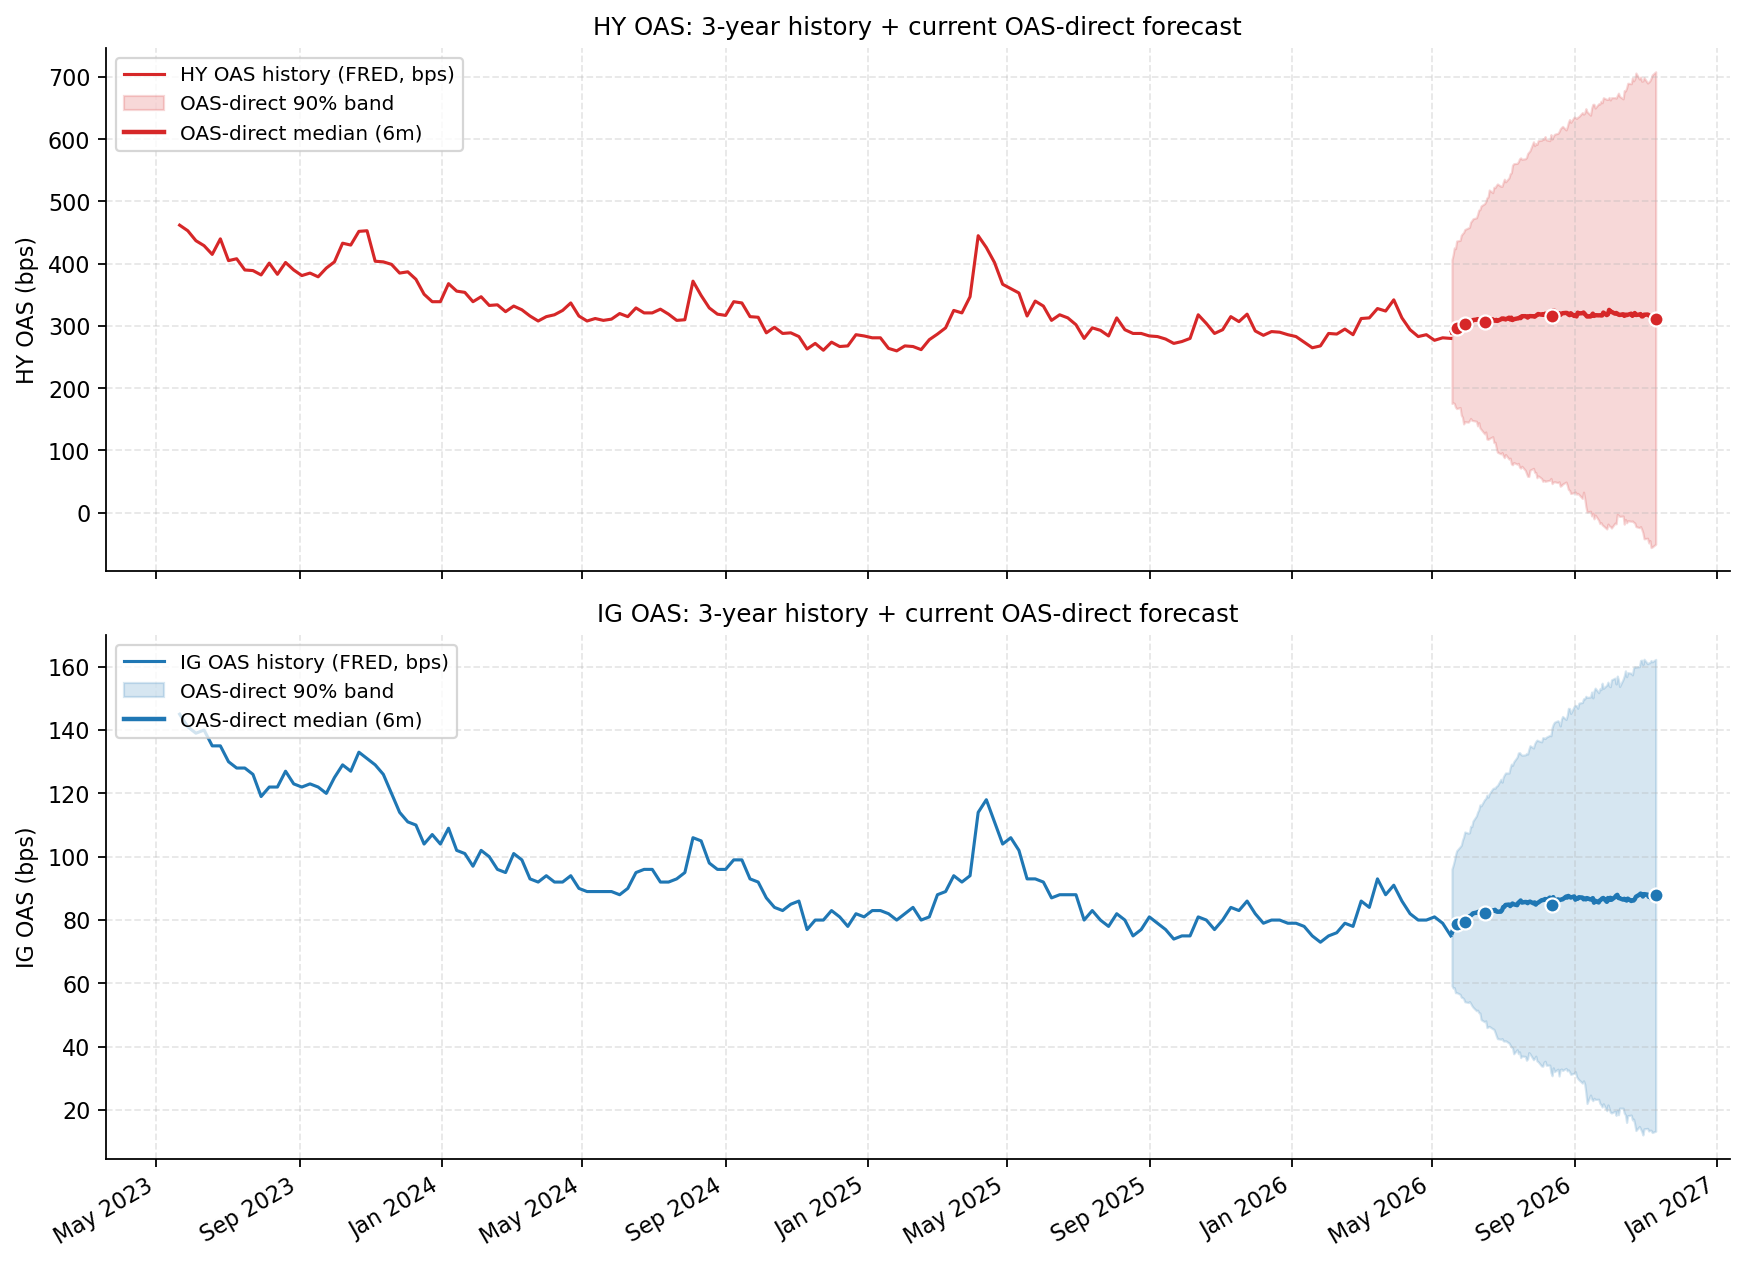

In [14]:
display(Image(filename=str(FIG / '16_oas_history_with_forecast.png')))

---
## Appendix — full figure + table index

Everything available, in case you need a visual not surfaced above.

In [15]:
print('Figures:')
for p in sorted(FIG.glob('*.png')):
    print(f'  dist/v5/report/figures/{p.name}')
print()
print('Tables (CSV + MD pair each):')
for p in sorted(TBL.glob('*.md')):
    print(f'  dist/v5/report/tables/{p.name}')

Figures:
  dist/v5/report/figures/01_hit_rate_HY.png
  dist/v5/report/figures/01_hit_rate_IG.png
  dist/v5/report/figures/02_rmse_HY.png
  dist/v5/report/figures/02_rmse_IG.png
  dist/v5/report/figures/03_bsts_vs_rw_hit_rate.png
  dist/v5/report/figures/04_inclusion_HY.png
  dist/v5/report/figures/04_inclusion_IG.png
  dist/v5/report/figures/05_risk_index_weekly_HY.png
  dist/v5/report/figures/05_risk_index_weekly_IG.png
  dist/v5/report/figures/06_risk_index_daily.png
  dist/v5/report/figures/07_calibration_coverage.png
  dist/v5/report/figures/08_forecast_fan_HY.png
  dist/v5/report/figures/08_forecast_fan_IG.png
  dist/v5/report/figures/09_rmse_vs_horizon.png
  dist/v5/report/figures/10_oas_proxy_scatter.png
  dist/v5/report/figures/11_topic_vs_category_share.png
  dist/v5/report/figures/12_forecast_vs_baselines_HY.png
  dist/v5/report/figures/12_forecast_vs_baselines_IG.png
  dist/v5/report/figures/13_top5_inclusion_side_by_side.png
  dist/v5/report/figures/14_oas_implied_fan_HY.pn